# Домашнее задание 4.

## 1. Загрузка данных

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
df = pd.read_csv('loan_prediction_dataset.csv')
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


## 2. Основная информация о датасете

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


## 3. Таблица пропусков

In [8]:
missing_abs = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    'Пропуски (абс.)': missing_abs,
    'Пропуски (%)': missing_pct
})

missing_table = missing_table[missing_table['Пропуски (абс.)'] > 0].sort_values('Пропуски (%)', ascending=False)
missing_table

,Пропуски (абс.),Пропуски (%)
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


Наибольшая доля пропусков — в `Credit_History`, `Self_Employed`, `LoanAmount`, `Dependents`, `Loan_Amount_Term`, `Gender` и `Married`. Ни один столбец не превышает порог в ~8%, что позволяет корректно заполнить пропуски без существенной потери информации.

## 4. Визуализация пропусков

### Матрица пропусков

C:\Users\petre\AppData\Local\Temp\ipykernel_13252\179815047.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


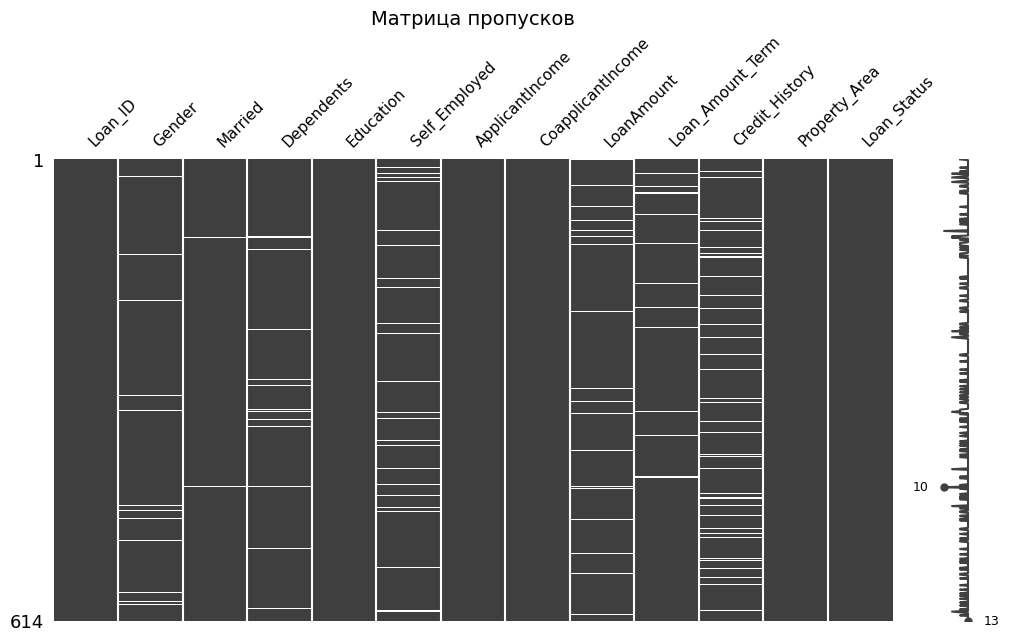

In [9]:
msno.matrix(df, figsize=(12, 6), fontsize=11, sparkline=True)
plt.title('Матрица пропусков', fontsize=14)
plt.tight_layout()
plt.show()

### Тепловая карта пропусков

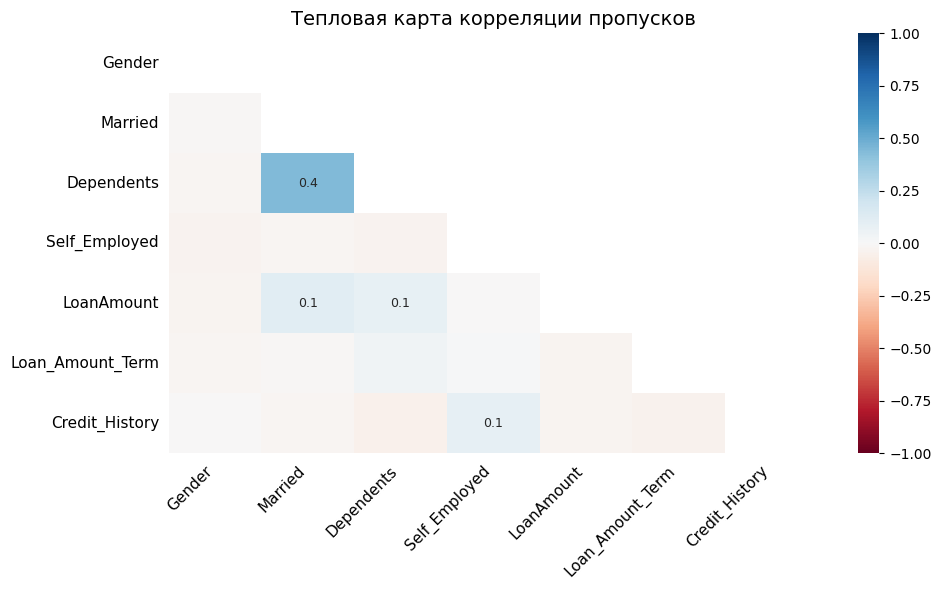

In [10]:
msno.heatmap(df, figsize=(10, 6), fontsize=11)
plt.title('Тепловая карта корреляции пропусков', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Интерпретация графиков

**Матрица пропусков:** белые полосы обозначают отсутствующие значения. Пропуски распределены по датасету достаточно равномерно, без крупных блоков — это говорит о случайном характере пропусков (MCAR/MAR). Столбцы `Credit_History` и `Self_Employed` имеют чуть больше белых полос, что согласуется с таблицей выше.

**Тепловая карта:** показывает корреляцию между фактами пропуска в разных столбцах. Значения близки к нулю — значимых совместных паттернов пропусков нет. Пропуски в одном признаке не связаны систематически с пропусками в другом, что подтверждает предположение о случайности пропусков и позволяет заполнять их независимо друг от друга.

## 6. Разделение признаков с пропусками на числовые и категориальные

In [11]:
cols_with_missing = df.columns[df.isnull().any()].tolist()

num_missing = [c for c in cols_with_missing if df[c].dtype in ['float64', 'int64']]
cat_missing = [c for c in cols_with_missing if df[c].dtype == 'object']

print('Числовые признаки с пропусками:', num_missing)
print('Категориальные признаки с пропусками:', cat_missing)

Числовые признаки с пропусками: ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Категориальные признаки с пропусками: ['Gender', 'Married', 'Dependents', 'Self_Employed']


К числовым относятся `LoanAmount`, `Loan_Amount_Term`, `Credit_History` — они хранятся как `float64`. К категориальным — `Gender`, `Married`, `Dependents`, `Self_Employed` — тип `object`.

## 7. Заполнение пропусков

**Стратегия заполнения:**

- **Категориальные признаки** → заполняем **модой** (наиболее частым значением). Для категориальных переменных мода — стандартный и статистически корректный метод, поскольку среднее/медиана для них не определены.
- **`LoanAmount`** → заполняем **медианой**. Распределение суммы кредита скошено вправо (есть выбросы), поэтому медиана устойчивее среднего.
- **`Loan_Amount_Term`** → заполняем **модой** (360). Несмотря на числовой тип, этот признак принимает ограниченный набор дискретных значений, а подавляющее большинство кредитов имеют срок 360 месяцев.
- **`Credit_History`** → заполняем **модой** (1.0). Признак бинарный (0/1), поэтому мода — наиболее подходящий метод.

In [12]:
stats_before = df.describe(include='all').T
stats_before_num = df[num_missing].describe()
stats_before_cat = df[cat_missing].describe()

In [13]:
for col in cat_missing:
    df[col].fillna(df[col].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

C:\Users\petre\AppData\Local\Temp\ipykernel_13252\3794930431.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\petre\AppData\Local\Temp\ipykernel_13252\3794930431.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

## 8. Проверка корректности заполнения

In [14]:
print('Общее число пропусков после заполнения:', df.isnull().sum().sum())
df.isnull().sum()

Общее число пропусков после заполнения: 0


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Все пропуски успешно заполнены — ни в одном столбце не осталось пропущенных значений.

## 9. Сравнение статистик до и после заполнения

In [15]:
stats_after_num = df[num_missing].describe()

comparison_num = pd.concat(
    [stats_before_num, stats_after_num],
    axis=1,
    keys=['До заполнения', 'После заполнения']
)
comparison_num

До заполнения                                 После заполнения  \
         LoanAmount Loan_Amount_Term Credit_History       LoanAmount   
count    592.000000        600.00000     564.000000       614.000000   
mean     146.412162        342.00000       0.842199       145.752443   
std       85.587325         65.12041       0.364878        84.107233   
min        9.000000         12.00000       0.000000         9.000000   
25%      100.000000        360.00000       1.000000       100.250000   
50%      128.000000        360.00000       1.000000       128.000000   
75%      168.000000        360.00000       1.000000       164.750000   
max      700.000000        480.00000       1.000000       700.000000   

                                       
      Loan_Amount_Term Credit_History  
count       614.000000     614.000000  
mean        342.410423       0.855049  
std          64.428629       0.352339  
min          12.000000       0.000000  
25%         360.000000       1.000000  
50%         360.000000       1.000000  
75%         360.000000       1.000000  
max         480.000000       1.000000

In [16]:
stats_after_cat = df[cat_missing].describe()

comparison_cat = pd.concat(
    [stats_before_cat, stats_after_cat],
    axis=1,
    keys=['До заполнения', 'После заполнения']
)
comparison_cat

До заполнения                                  После заполнения  \
              Gender Married Dependents Self_Employed           Gender   
count            601     611        599           582              614   
unique             2       2          4             2                2   
top             Male     Yes          0            No             Male   
freq             489     398        345           500              502   

                                         
       Married Dependents Self_Employed  
count      614        614           614  
unique       2          4             2  
top        Yes          0            No  
freq       401        360           532

**Числовые признаки:** для `LoanAmount` медиана и среднее практически не изменились — заполнение медианой сохранило центральную тенденцию. Стандартное отклонение немного уменьшилось, что ожидаемо при замене пропусков на центральное значение. Для `Loan_Amount_Term` и `Credit_History` значения `count` выросли до 614, а статистики почти не сдвинулись, так как мода совпадает с доминирующим значением.

**Категориальные признаки:** `count` увеличился до 614 для всех столбцов. Топ-категория (`top`) и её частота (`freq`) выросли, остальные показатели стабильны. Заполнение модой не исказило распределение категорий.